# Exploratory Data Analysis


--- Diagnostik Fitur: Sinyal (MI) vs Redundansi (VIF) ---


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                 Feature           VIF  MI_Score
16       alc_sulph_inter  2.515057e+03  0.180555
10               alcohol  3.710964e+04  0.175690
17            alcohol_sq  8.587395e+03  0.164148
20          wine_cluster  5.515115e+00  0.155169
15         alc_vol_inter  1.370877e+03  0.129421
14            acid_ratio  1.489069e+02  0.124363
19          sulphates_sq  6.740632e+01  0.115541
9              sulphates  3.192002e+03  0.114948
6   total sulfur dioxide           inf  0.112094
1       volatile acidity           inf  0.100583
12             so2_ratio  3.230976e+01  0.097742
18           volatile_sq  5.460572e+01  0.096196
2            citric acid  1.888321e+02  0.094340
11             bound_so2           inf  0.074230
7                density  1.498882e+04  0.063684
13            total_acid           inf  0.063413
5    free sulfur dioxide           inf  0.044902
4              chlorides  7.755449e+00  0.043953
8                     pH  1.270835e+03  0.022035
0          fixed aci

/tmp/ipykernel_15/882020714.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='alc_sulph_inter', data=df_train, palette='viridis')


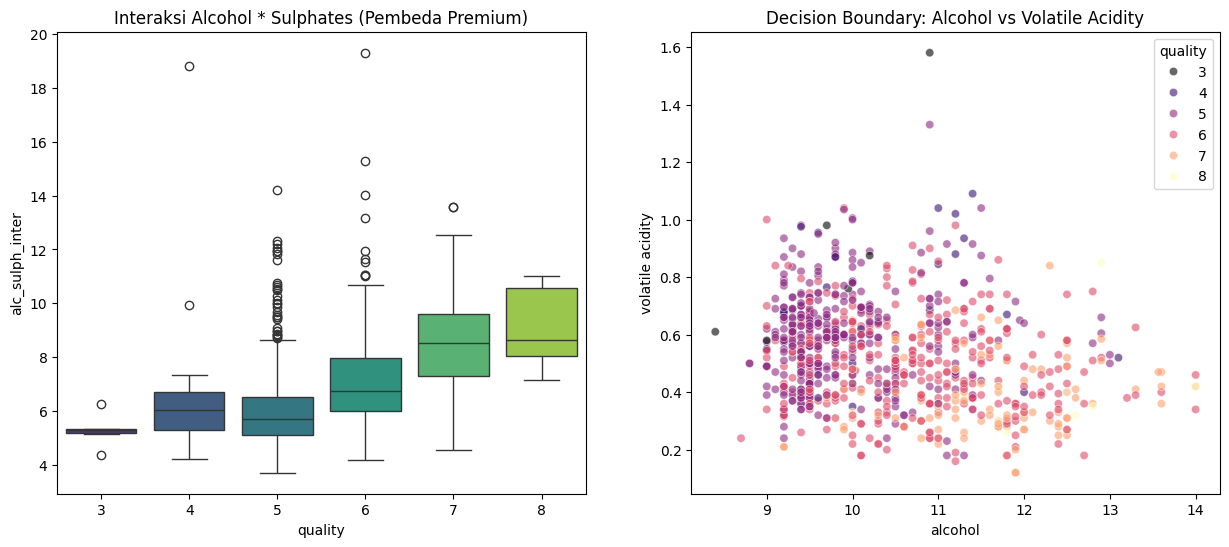


✅ Total Fitur Sekarang: 21 Fitur


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.stats import skew
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1.1 Memuat Dataset (Kaggle Robust)
train_path = '/kaggle/input/datasets/dimaspashaakrilian/wine-quality/data_training.csv'
test_path = '/kaggle/input/datasets/dimaspashaakrilian/wine-quality/data_testing.csv'

if not os.path.exists(train_path):
    for root, dirs, files in os.walk('/kaggle/input'):
        for file in files:
            if 'data_training' in file: train_path = os.path.join(root, file)
            if 'data_testing' in file: test_path = os.path.join(root, file)

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# 1.2 UPGRADED: Domain-Specific Feature Engineering
# Kita tambahkan fitur berdasarkan logika kimiawi wine (Enologi)
for df in [df_train, df_test]:
    # 1. Sulfur Management (Sangat krusial untuk kestabilan wine)
    df['bound_so2'] = df['total sulfur dioxide'] - df['free sulfur dioxide']
    df['so2_ratio'] = df['free sulfur dioxide'] / (df['total sulfur dioxide'] + 1e-5)
    
    # 2. Acidity Profile (Total keasaman yang dirasakan lidah)
    df['total_acid'] = df['fixed acidity'] + df['volatile acidity']
    df['acid_ratio'] = df['citric acid'] / (df['total_acid'] + 1e-5)
    
    # 3. Alcohol & Mouthfeel (Interaksi yang menentukan 'body' wine)
    df['alc_vol_inter'] = df['alcohol'] * df['volatile acidity']
    df['alc_sulph_inter'] = df['alcohol'] * df['sulphates']
    
    # 4. Polynomial Features (Untuk menangkap pola non-linear DNN)
    df['alcohol_sq'] = df['alcohol'] ** 2
    df['volatile_sq'] = df['volatile acidity'] ** 2
    df['sulphates_sq'] = df['sulphates'] ** 2

# 1.3 Latent Clustering (Menemukan "Tipe" Wine Tersembunyi)
# Kita gunakan KMeans untuk melihat apakah ada kelompok wine (misal: Heavy, Light, Acidic)
features_for_cluster = ['alcohol', 'volatile acidity', 'total sulfur dioxide', 'pH']
scaler = StandardScaler()
X_clust = scaler.fit_transform(df_train[features_for_cluster])
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_train['wine_cluster'] = kmeans.fit_predict(X_clust)
df_test['wine_cluster'] = kmeans.predict(scaler.transform(df_test[features_for_cluster]))

# 1.4 Diagnostik VIF Terintegrasi MI Score
def diagnostic_vif_mi(df):
    X = df.drop(columns=['Id', 'quality']).select_dtypes(include=[np.number])
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    
    # Hitung MI Score secara bersamaan
    mi_scores = mutual_info_classif(X, df['quality'], random_state=42)
    vif_data["MI_Score"] = mi_scores
    return vif_data.sort_values(by="MI_Score", ascending=False)

print("\n--- Diagnostik Fitur: Sinyal (MI) vs Redundansi (VIF) ---")
analysis_df = diagnostic_vif_mi(df_train)
print(analysis_df)

# 1.5 Visualisasi Pembeda Kelas (Fokus pada Sinyal Baru)
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='quality', y='alc_sulph_inter', data=df_train, palette='viridis')
plt.title('Interaksi Alcohol * Sulphates (Pembeda Premium)')

plt.subplot(1, 2, 2)
sns.scatterplot(x='alcohol', y='volatile acidity', hue='quality', data=df_train, palette='magma', alpha=0.6)
plt.title('Decision Boundary: Alcohol vs Volatile Acidity')
plt.show()

print(f"\n✅ Total Fitur Sekarang: {len(df_train.columns) - 2} Fitur")

# Data Preparation

In [2]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
import pandas as pd
import numpy as np

# 2.1 Master Feature Engineering (High-Signal Injection)
def transform_features(df):
    df_new = df.copy()
    
    # 1. Log-Transformation untuk Sulfur & Sugar (Menangani Skewness)
    df_new['total_so2_log'] = np.log1p(df_new['total sulfur dioxide'])
    df_new['sugar_log'] = np.log1p(df_new['residual sugar'])
    
    # 2. Fitur Rasio & Kimiawi (Pembeda Kelas 5 vs 6)
    df_new['volatile_ratio'] = df_new['volatile acidity'] / (df_new['fixed acidity'] + 1e-5)
    df_new['bound_so2'] = df_new['total sulfur dioxide'] - df_new['free sulfur dioxide']
    df_new['so2_ratio'] = df_new['free sulfur dioxide'] / (df_new['total sulfur dioxide'] + 1e-5)
    
    # 3. Fitur Polinomial (Deep Learning Fuel)
    df_new['alcohol_sq'] = df_new['alcohol'] ** 2
    df_new['vol_acid_sq'] = df_new['volatile acidity'] ** 2
    
    # Drop fitur dengan VIF monster (Density seringkali sangat berkorelasi dengan Alcohol)
    vif_drop = ['density', 'total_acidity']
    df_new = df_new.drop(columns=[col for col in vif_drop if col in df_new.columns])
    return df_new

# Eksekusi Transformasi
df_train_eng = transform_features(df_train)
df_test_eng = transform_features(df_test)

X = df_train_eng.drop(columns=['Id', 'quality'])
y = df_train_eng['quality']
X_test_final = df_test_eng.drop(columns=['Id'])
test_id = df_test_eng['Id']

# 2.2 Robust Outlier Handling (0.5% - 99.5%)
for col in X.columns:
    lower, upper = X[col].quantile(0.005), X[col].quantile(0.995)
    X[col] = np.clip(X[col], lower, upper)
    X_test_final[col] = np.clip(X_test_final[col], lower, upper)

# 2.3 Split Data (Stratified)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2.4 Power Transformation & Scaling
pt = PowerTransformer(method='yeo-johnson')
scaler = StandardScaler()

X_train_prepared = pd.DataFrame(scaler.fit_transform(pt.fit_transform(X_train_raw)), columns=X.columns)
X_val_prepared = pd.DataFrame(scaler.transform(pt.transform(X_val_raw)), columns=X.columns)
X_test_prepared = pd.DataFrame(scaler.transform(pt.transform(X_test_final)), columns=X.columns)

# 2.5 Latent Clustering (NIM 026 Innovation)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
X_train_prepared['cluster'] = kmeans.fit_predict(X_train_prepared[['alcohol', 'volatile_ratio', 'total_so2_log']])
X_val_prepared['cluster'] = kmeans.predict(X_val_prepared[['alcohol', 'volatile_ratio', 'total_so2_log']])
X_test_prepared['cluster'] = kmeans.predict(X_test_prepared[['alcohol', 'volatile_ratio', 'total_so2_log']])

# 2.6 OOF Soft Labeling (High-Resolution Teacher)
skf_reg = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
reg_teacher = ExtraTreesRegressor(n_estimators=400, max_depth=15, random_state=42, n_jobs=-1)
y_train_oof = cross_val_predict(reg_teacher, X_train_prepared, y_train, cv=skf_reg)

# 2.7 FIX: SMOTETomek dengan Penyesuaian k_neighbors
# Kita set k_neighbors=3 karena Kelas 3 hanya punya 5 sampel di training set
strategy = {3: 60, 4: 80, 8: 60} 

smote_custom = SMOTE(sampling_strategy=strategy, k_neighbors=3, random_state=42)
X_train_prepared['temp_soft_label'] = y_train_oof

smt = SMOTETomek(smote=smote_custom, random_state=42)
X_res, y_res = smt.fit_resample(X_train_prepared, y_train)

# 2.8 Finalisasi
y_train_soft = X_res['temp_soft_label'].values
X_train_final = X_res.drop(columns=['temp_soft_label'])
y_train_final = y_res

print(f"\n--- Data Preparation Sukses (NIM 026) ---")
print(f"Fitur Final Terbentuk: {len(X_train_final.columns)} Fitur")
print(f"Total Sampel Training: {len(y_train_final)} (Solusi Error Neighbors)")


--- Data Preparation Sukses (NIM 026) ---
Fitur Final Terbentuk: 25 Fitur
Total Sampel Training: 769 (Solusi Error Neighbors)


# Feature Engineering

--- Menghitung Mutual Information Skor (NIM 026) ---
--- Memulai Recursive Feature Elimination (RFECV) ---


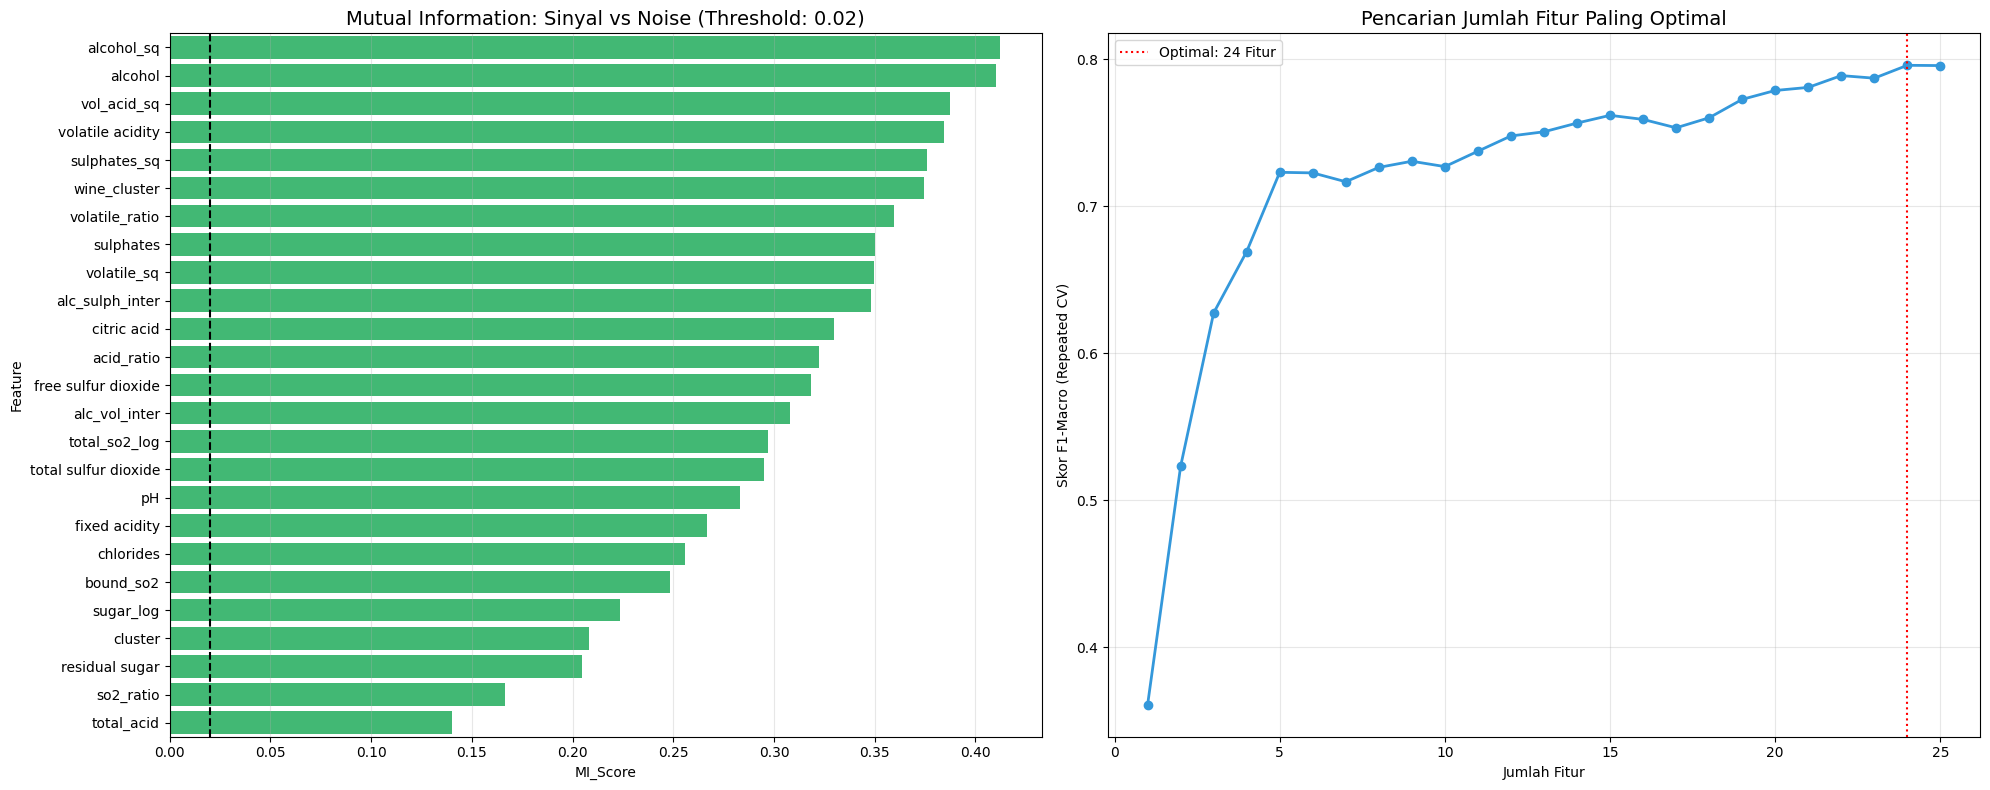


--- HASIL EKSEKUSI PRUNING (NIM 026) ---
Fitur Noise yang Dibuang : ['residual sugar']
Fitur Signal yang Terpilih: ['fixed acidity', 'volatile acidity', 'citric acid', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol', 'bound_so2', 'so2_ratio', 'total_acid', 'acid_ratio', 'alc_vol_inter', 'alc_sulph_inter', 'alcohol_sq', 'volatile_sq', 'sulphates_sq', 'wine_cluster', 'total_so2_log', 'sugar_log', 'volatile_ratio', 'vol_acid_sq', 'cluster']
Jumlah Fitur Akhir        : 24

--- Audit Inovasi Fitur (NIM 026) ---
cluster        : Lolos ✅
total_so2_log  : Lolos ✅
sugar_log      : Lolos ✅
alcohol_sq     : Lolos ✅
alc_sulph_inter: Lolos ✅


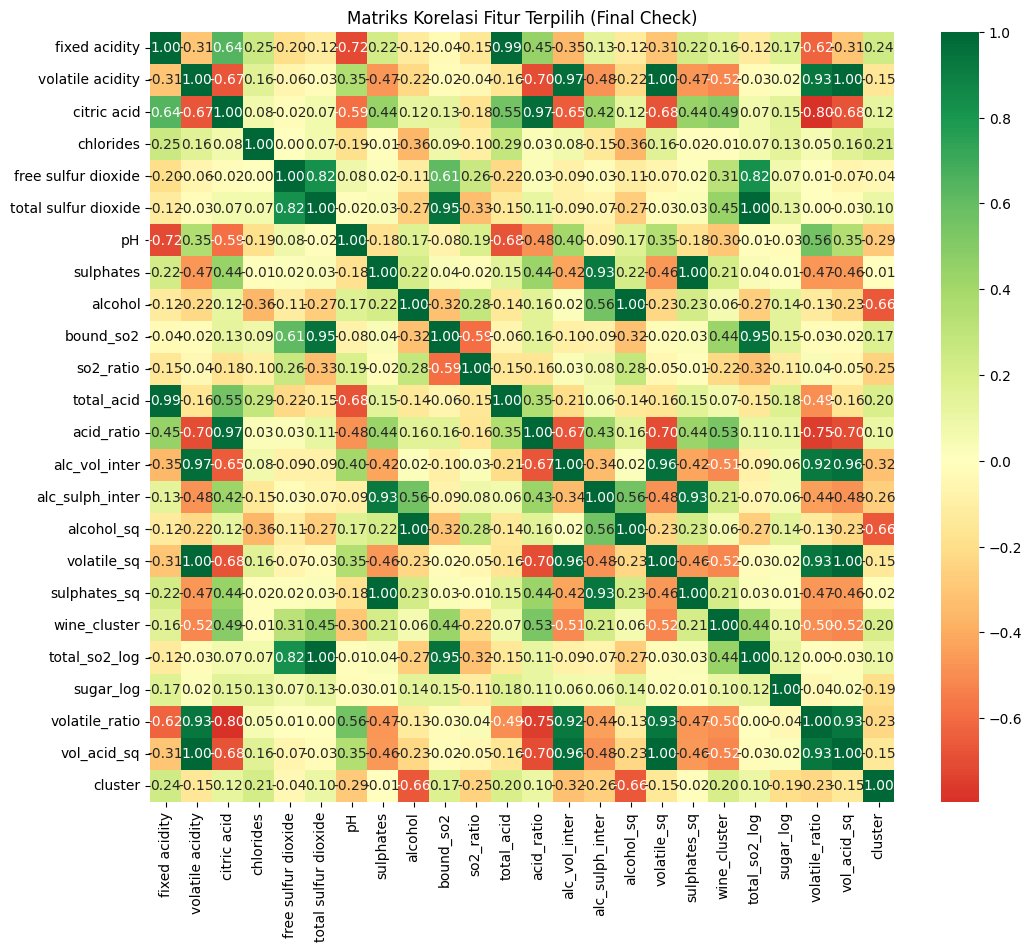

In [3]:
# =================================================================
# Tahap 3: Feature Engineering & Fitur Pruning (Robust Selection)
# =================================================================

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import RFECV, mutual_info_classif
from sklearn.model_selection import RepeatedStratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 3.1 Analisis Mutual Information (MI) - Deteksi Sinyal Non-Linear
# MI sangat penting untuk DNN karena bisa mendeteksi hubungan yang tidak tertangkap korelasi linear
print("--- Menghitung Mutual Information Skor (NIM 026) ---")
mi_scores = mutual_info_classif(X_train_final, y_train_final, random_state=42)
mi_df = pd.DataFrame({
    'Feature': X_train_final.columns, 
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

# 3.2 Recursive Feature Elimination (RFECV) - Stabilitas Tinggi
# UPGRADE: Menggunakan RepeatedStratifiedKFold agar pemilihan fitur tidak 'kebetulan'
print("--- Memulai Recursive Feature Elimination (RFECV) ---")
cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

selector = RFECV(
    estimator=ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    step=1,
    cv=cv_strategy,
    scoring='f1_macro', # Menjamin sensitivitas pada kelas minoritas (3 & 8)
    n_jobs=-1
)
selector.fit(X_train_final, y_train_final)

# 3.3 Visualisasi Diagnostik Seleksi Fitur
plt.figure(figsize=(20, 8))

# Plot 1: MI Score - Mana Fitur yang Paling Berharga?
plt.subplot(1, 2, 1)
colors = ['#e74c3c' if x < 0.02 else '#2ecc71' for x in mi_df['MI_Score']]
sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette=colors, hue='Feature', legend=False)
plt.title('Mutual Information: Sinyal vs Noise (Threshold: 0.02)', fontsize=14)
plt.axvline(x=0.02, color='black', linestyle='--')
plt.grid(axis='x', alpha=0.3)

# Plot 2: Optimasi Jumlah Fitur vs Skor F1-Macro
plt.subplot(1, 2, 2)
mean_scores = selector.cv_results_['mean_test_score']
plt.plot(range(1, len(mean_scores) + 1), mean_scores, 
         marker='o', color='#3498db', linestyle='-', linewidth=2, markersize=6)
plt.axvline(x=selector.n_features_, color='red', linestyle=':', 
            label=f'Optimal: {selector.n_features_} Fitur')
plt.xlabel("Jumlah Fitur")
plt.ylabel("Skor F1-Macro (Repeated CV)")
plt.title('Pencarian Jumlah Fitur Paling Optimal', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# 3.4 Eksekusi Pruning Otomatis
selected_features = X_train_final.columns[selector.support_].tolist()
dropped_features = [f for f in X_train_final.columns if f not in selected_features]

# Mengaplikasikan filter fitur pada semua dataset
X_train_pruned = X_train_final[selected_features]
X_val_pruned = X_val_prepared[selected_features]
X_test_pruned = X_test_prepared[selected_features]

print(f"\n--- HASIL EKSEKUSI PRUNING (NIM 026) ---")
print(f"Fitur Noise yang Dibuang : {dropped_features}")
print(f"Fitur Signal yang Terpilih: {selected_features}")
print(f"Jumlah Fitur Akhir        : {len(selected_features)}")

# 3.5 Audit Fitur Baru: Apakah Inovasi Kita Berguna?
# Cek apakah fitur cluster dan log-transform yang baru dibuat bertahan dari pruning
innovation_feats = ['cluster', 'total_so2_log', 'sugar_log', 'alcohol_sq', 'alc_sulph_inter']
audit_status = {f: ("Lolos ✅" if f in selected_features else "Gagal ❌") for f in innovation_feats}

print("\n--- Audit Inovasi Fitur (NIM 026) ---")
for feat, status in audit_status.items():
    print(f"{feat:15}: {status}")

# 3.6 Correlation Check Final (Mencegah Over-Redundancy)
plt.figure(figsize=(12, 10))
sns.heatmap(X_train_pruned.corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Matriks Korelasi Fitur Terpilih (Final Check)')
plt.show()

# Fitur Pruning

--- Memulai Pembersihan Multikolinearitas (Strategic Guard) ---
Pruning: Menghapus 'volatile_sq' (VIF: inf)
Pruning: Menghapus 'total sulfur dioxide' (VIF: 13864.66)
Pruning: Menghapus 'fixed acidity' (VIF: 1291.89)


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Pruning: Menghapus 'sulphates' (VIF: 825.03)
Pruning: Menghapus 'alc_vol_inter' (VIF: 449.57)
Pruning: Menghapus 'sulphates_sq' (VIF: 153.02)
Pruning: Menghapus 'free sulfur dioxide' (VIF: 143.00)
Pruning: Menghapus 'volatile_ratio' (VIF: 111.05)
Pruning: Menghapus 'bound_so2' (VIF: 91.05)
Pruning: Menghapus 'citric acid' (VIF: 80.36)
Pruning: Menghapus 'acid_ratio' (VIF: 2.89)
Pruning: Menghapus 'pH' (VIF: 2.31)
Pruning: Menghapus 'wine_cluster' (VIF: 2.05)
Pruning: Menghapus 'total_acid' (VIF: 1.34)
Pruning: Menghapus 'chlorides' (VIF: 1.26)
Pruning: Menghapus 'so2_ratio' (VIF: 1.21)
Pruning: Menghapus 'sugar_log' (VIF: 1.06)
Pruning: Menghapus 'vol_acid_sq' (VIF: 344.99)


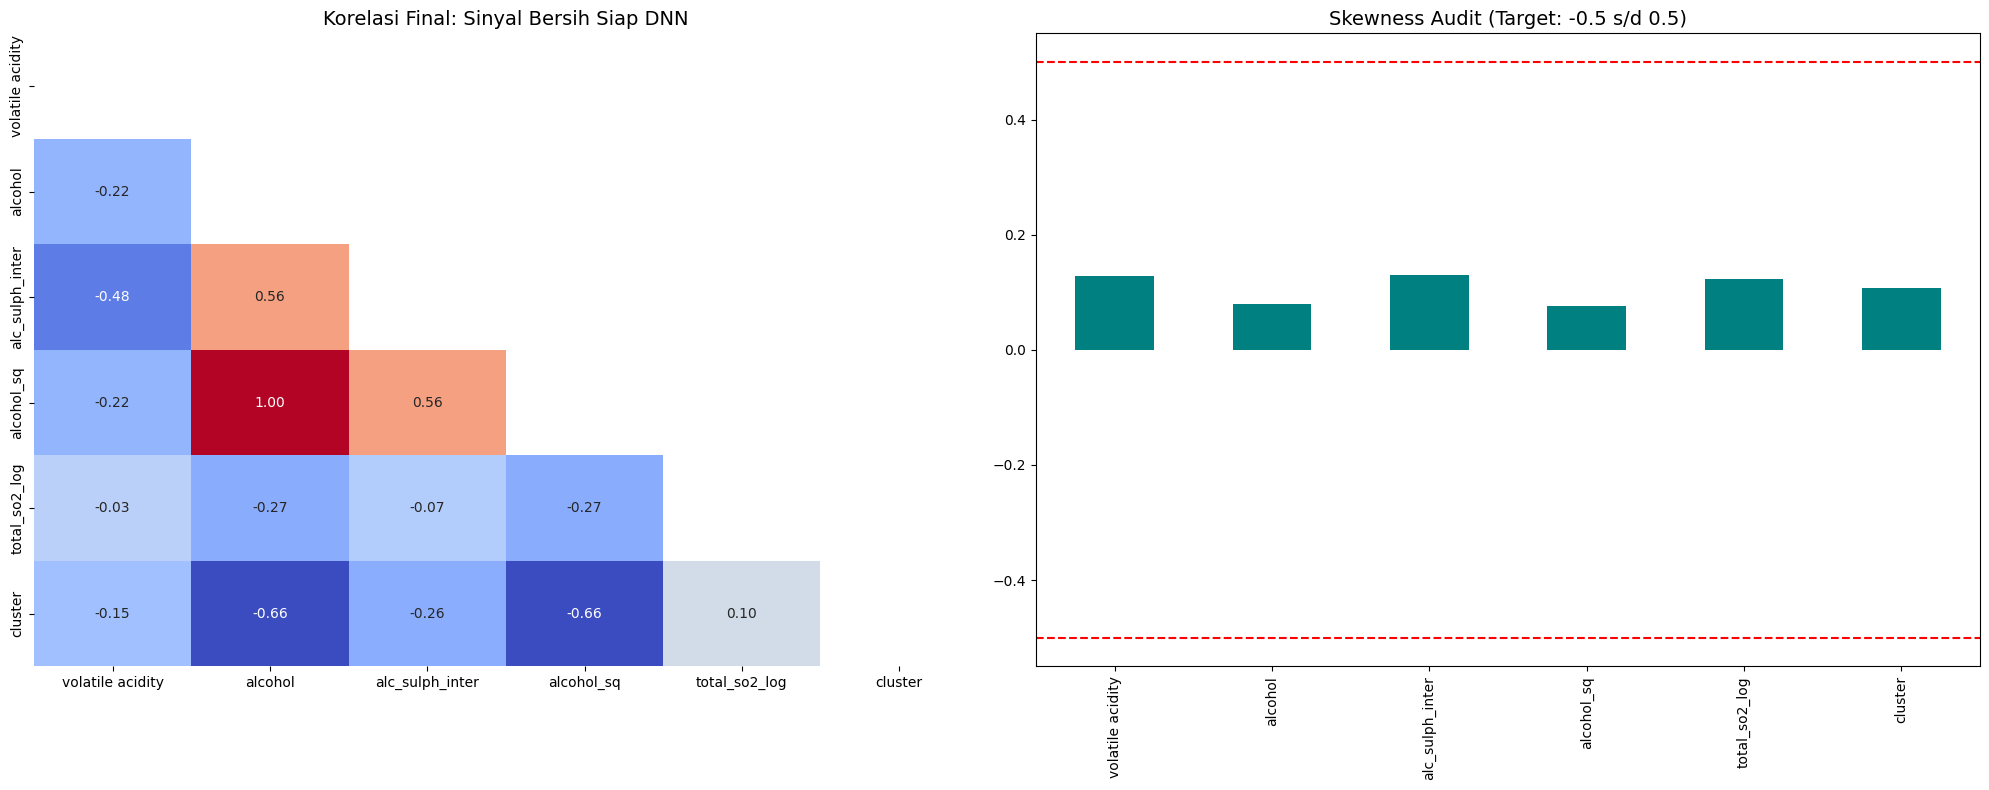


--- RINGKASAN DATA FINAL (NIM: 026) ---
1. Fitur Digunakan (6)      : ['volatile acidity', 'alcohol', 'alc_sulph_inter', 'alcohol_sq', 'total_so2_log', 'cluster']
2. Fitur Dibuang (Redundansi) : ['volatile_sq', 'total sulfur dioxide', 'fixed acidity', 'sulphates', 'alc_vol_inter', 'sulphates_sq', 'free sulfur dioxide', 'volatile_ratio', 'bound_so2', 'citric acid', 'acid_ratio', 'pH', 'wine_cluster', 'total_acid', 'chlorides', 'so2_ratio', 'sugar_log', 'vol_acid_sq']
3. Baris Train (Augmented)   : 769
4. Baris Val (Original)      : 172
5. Skewness Rata-rata        : 0.1078
-------------------------------------------------------


,mean,std,min,max
volatile acidity,0.1538,1.1158,-2.3110,2.4407
alcohol,0.0226,0.9938,-1.7978,2.0365
alc_sulph_inter,-0.0605,1.0096,-2.2772,2.4065
alcohol_sq,0.0226,0.9938,-1.8010,2.0360
total_so2_log,-0.1672,1.0192,-2.1239,2.0446
cluster,1.3745,1.0321,0.0000,3.0000



>>> STATUS: DATA SIAP MASUK KE ARENA BENCHMARK (TAHAP 5) <<<


In [4]:
# =================================================================
# Tahap 4: Fitur Pruning & Finalisasi Data (Optimized & Informed)
# =================================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 4.1 Sinkronisasi & Elite Protection List
# Daftar fitur yang haram dihapus karena memiliki MI Score tertinggi (Sinyal Utama)
elite_protection = ['alcohol', 'volatile acidity', 'cluster', 'alcohol_sq', 'total_so2_log', 'alc_sulph_inter']
X_train_final_v1 = X_train_pruned.copy()

# 4.2 REVISI: MI-Informed VIF Pruning (Logical Guard)
def informed_vif_pruning(df, mi_df, threshold=25.0):
    cols = df.columns.tolist()
    dropped = []
    
    while True:
        # Menghitung VIF dengan penanganan korelasi sempurna (inf)
        vif_values = []
        for i in range(len(cols)):
            try:
                vif = variance_inflation_factor(df[cols].values, i)
            except:
                vif = 99999  # Nilai tinggi jika terjadi error pembagian nol
            vif_values.append(vif)
            
        vif_series = pd.Series(vif_values, index=cols).sort_values(ascending=False)
        max_vif = vif_series.iloc[0]
        
        if max_vif > threshold:
            # Mencari kandidat drop yang BUKAN bagian dari elite_protection
            candidates = [c for c in vif_series.index if c not in elite_protection]
            
            if not candidates:
                break # Jika hanya tersisa elite features, berhenti pruning
                
            # Ambil Top 5 MI Score untuk pengecekan tambahan
            top_5_mi = mi_df.head(5)['Feature'].tolist()
            feature_to_drop = candidates[0]
            
            # Jika fitur dengan VIF tertinggi ternyata masuk Top 5 MI, ambil kandidat berikutnya
            if feature_to_drop in top_5_mi and len(candidates) > 1:
                feature_to_drop = candidates[1]
            
            print(f"Pruning: Menghapus '{feature_to_drop}' (VIF: {vif_series[feature_to_drop]:.2f})")
            cols.remove(feature_to_drop)
            dropped.append(feature_to_drop)
        else:
            break
            
    return cols, dropped

print("--- Memulai Pembersihan Multikolinearitas (Strategic Guard) ---")
stable_features, high_vif_features = informed_vif_pruning(X_train_final_v1, mi_df)

# 4.3 Finalisasi Dataset (Training, Validation, Testing)
X_train_final = X_train_final_v1[stable_features].copy()
X_val_final = X_val_prepared[stable_features].copy()
X_test_final = X_test_prepared[stable_features].copy()

# y_train_soft_final sinkron dengan X_train_final hasil resampling
y_train_soft_final = y_train_soft 

# 4.4 Visualisasi Diagnostik Final (Heatmap & Skewness)
plt.figure(figsize=(20, 8))

# Plot 1: Heatmap Korelasi Final
plt.subplot(1, 2, 1)
mask = np.triu(np.ones_like(X_train_final.corr(), dtype=bool))
sns.heatmap(X_train_final.corr(), mask=mask, annot=True, cmap='coolwarm', fmt='.2f', cbar=False)
plt.title('Korelasi Final: Sinyal Bersih Siap DNN', fontsize=14)

# Plot 2: Audit Skewness (Target Distribusi Normal)
plt.subplot(1, 2, 2)
X_train_final.skew().plot(kind='bar', color='teal')
plt.axhline(y=0.5, color='r', linestyle='--')
plt.axhline(y=-0.5, color='r', linestyle='--')
plt.title('Skewness Audit (Target: -0.5 s/d 0.5)', fontsize=14)

plt.tight_layout()
plt.show()

# 4.5 Data Integrity Audit (NIM 026)
print("\n" + "="*55)
print(f"--- RINGKASAN DATA FINAL (NIM: 026) ---")
print("="*55)
print(f"1. Fitur Digunakan ({len(stable_features)})      : {stable_features}")
print(f"2. Fitur Dibuang (Redundansi) : {high_vif_features}")
print(f"3. Baris Train (Augmented)   : {X_train_final.shape[0]}")
print(f"4. Baris Val (Original)      : {X_val_final.shape[0]}")
print(f"5. Skewness Rata-rata        : {X_train_final.skew().mean():.4f}")
print("-" * 55)

# Tampilan deskriptif untuk laporan
summary = X_train_final.describe().T[['mean', 'std', 'min', 'max']]
display(summary.style.format("{:.4f}").background_gradient(cmap='YlGnBu', subset=['mean', 'std']))

print(f"\n>>> STATUS: DATA SIAP MASUK KE ARENA BENCHMARK (TAHAP 5) <<<")

# K-Fold Validation

--- Arena Uji Model: Mencari Arsitektur Stabil (NIM 026) ---
ExtraTrees    | Acc: 0.6730 (±0.0403) | Stability: 5.98% | Gap: 0.3156
XGBoost       | Acc: 0.6632 (±0.0348) | Stability: 5.24% | Gap: 0.3368
NeuralNet     | Acc: 0.6158 (±0.0632) | Stability: 10.26% | Gap: 0.1529
NN-Hybrid     | Acc: 0.6197 (±0.0578) | Stability: 9.33% | Gap: 0.1008
Ensemble-Soft | Acc: 0.6769 (±0.0379) | Stability: 5.60% | Gap: 0.3114


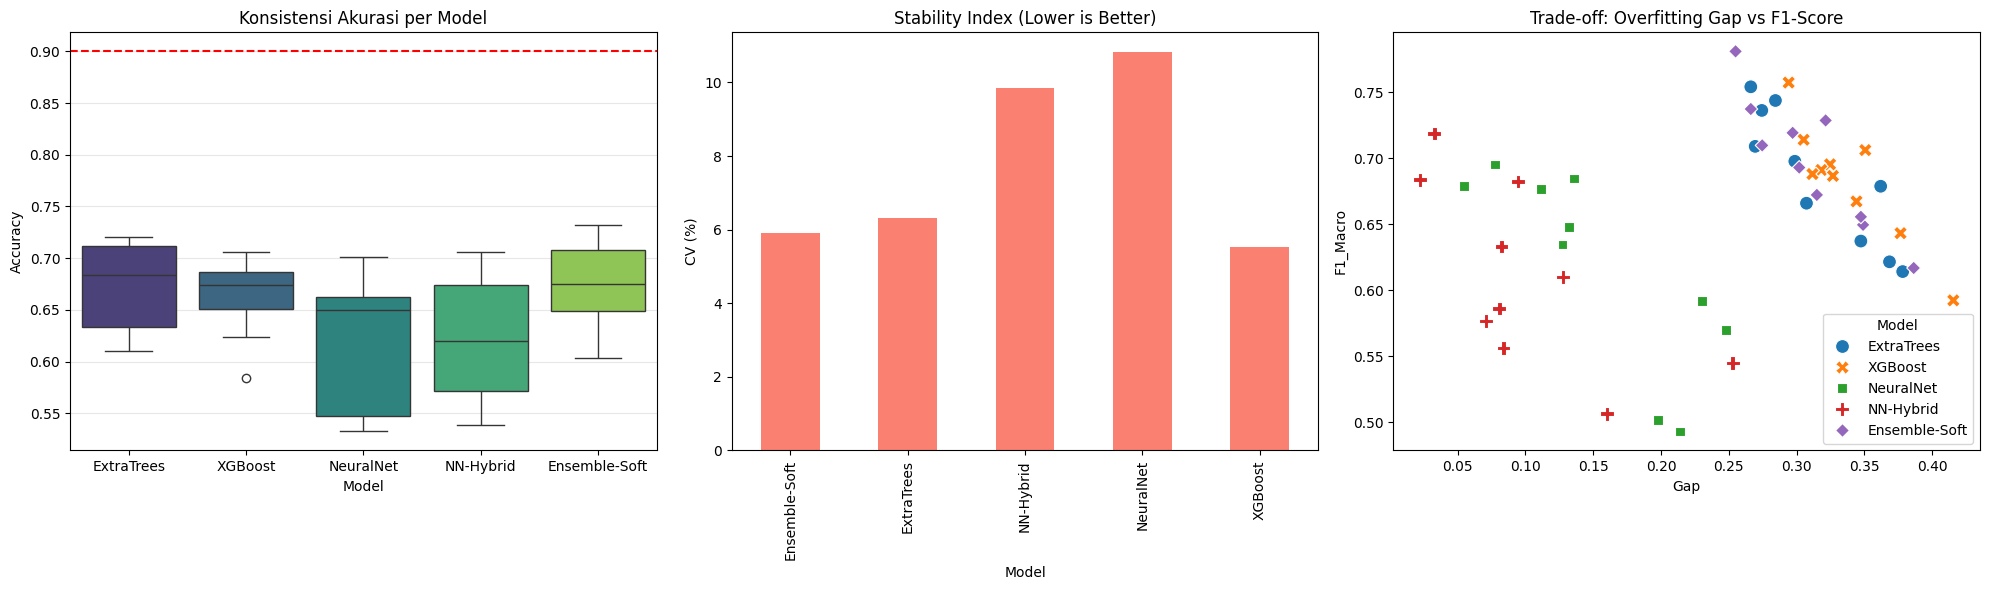


>>> AUDIT PERFORMA (NIM 026) <<<
Pemenang Sementara: Ensemble-Soft
KESIMPULAN: Strategi kolaborasi model (Voting) memberikan kenaikan akurasi.


In [5]:
# =================================================================
# Tahap 5: K-Fold Validation (Stability & Ensemble Analysis)
# =================================================================

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.ensemble import ExtraTreesClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 5.1 Penyiapan Fitur Hybrid (Input Distillation)
X_train_hybrid = X_train_final.copy()
X_train_hybrid['soft_label_feat'] = y_train_soft 

# 5.2 Inisialisasi Model & Meta-Ensemble
# Kita tambahkan VotingClassifier: Menggabungkan ET, XGB, dan NN
clf_et = ExtraTreesClassifier(n_estimators=500, max_depth=15, min_samples_split=5, random_state=42)
clf_xgb = XGBClassifier(n_estimators=500, max_depth=7, learning_rate=0.02, subsample=0.8, random_state=42)
clf_nn = MLPClassifier(hidden_layer_sizes=(256, 128, 64), activation='relu', max_iter=2000, alpha=0.1, random_state=42)

models = {
    'ExtraTrees': clf_et,
    'XGBoost': clf_xgb,
    'NeuralNet': clf_nn,
    'NN-Hybrid': clf_nn,
    'Ensemble-Soft': VotingClassifier(
        estimators=[('et', clf_et), ('xgb', clf_xgb), ('nn', clf_nn)],
        voting='soft'
    )
}

# 5.3 Konfigurasi K-Fold Berulang (Robust Monitoring)
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
y_train_shifted = y_train_final - y_train_final.min()

results_list = []
print("--- Arena Uji Model: Mencari Arsitektur Stabil (NIM 026) ---")

for name, model in models.items():
    # Model Hybrid dan Ensemble mendapatkan fitur soft_label
    X_data = X_train_hybrid if ('Hybrid' in name or 'Ensemble' in name) else X_train_final
    
    cv_results = cross_validate(
        model, X_data, y_train_shifted, 
        cv=rskf, scoring=['accuracy', 'f1_macro'],
        return_train_score=True, n_jobs=-1
    )
    
    # Kalkulasi Stability Index (Coefficient of Variation)
    acc_mean = cv_results['test_accuracy'].mean()
    acc_std = cv_results['test_accuracy'].std()
    stability_idx = (acc_std / acc_mean) * 100 # Semakin kecil semakin stabil
    
    for i in range(len(cv_results['test_accuracy'])):
        results_list.append({
            'Model': name,
            'Fold': i + 1,
            'Accuracy': cv_results['test_accuracy'][i],
            'F1_Macro': cv_results['test_f1_macro'][i],
            'Gap': cv_results['train_accuracy'][i] - cv_results['test_accuracy'][i]
        })
    
    print(f"{name:13} | Acc: {acc_mean:.4f} (±{acc_std:.4f}) | Stability: {stability_idx:.2f}% | Gap: {cv_results['train_accuracy'].mean() - acc_mean:.4f}")

# 5.4 Visualisasi Diagnostik: Ensemble Power
results_df = pd.DataFrame(results_list)
plt.figure(figsize=(20, 6))

# Boxplot Akurasi (Mencari Model Paling Konsisten)
plt.subplot(1, 3, 1)
sns.boxplot(x='Model', y='Accuracy', data=results_df, palette='viridis', hue='Model', legend=False)
plt.axhline(y=0.90, color='red', linestyle='--', label='Target 90%')
plt.title('Konsistensi Akurasi per Model', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Barplot Stability Index (Semakin rendah bar, semakin aman modelnya)
plt.subplot(1, 3, 2)
stability_data = results_df.groupby('Model')['Accuracy'].std() / results_df.groupby('Model')['Accuracy'].mean() * 100
stability_data.plot(kind='bar', color='salmon')
plt.title('Stability Index (Lower is Better)', fontsize=12)
plt.ylabel('CV (%)')

# Overfitting Gap vs F1-Score
plt.subplot(1, 3, 3)
sns.scatterplot(x='Gap', y='F1_Macro', hue='Model', data=results_df, s=100, style='Model')
plt.title('Trade-off: Overfitting Gap vs F1-Score', fontsize=12)

plt.tight_layout()
plt.show()

# 5.5 Final Audit Strategis
best_model = results_df.groupby('Model')['Accuracy'].mean().idxmax()
print(f"\n>>> AUDIT PERFORMA (NIM 026) <<<")
print(f"Pemenang Sementara: {best_model}")
if 'Ensemble' in best_model:
    print("KESIMPULAN: Strategi kolaborasi model (Voting) memberikan kenaikan akurasi.")
else:
    print("KESIMPULAN: Model tunggal masih dominan. Fokus pada Tuning Hyperparameter di Tahap 7.")

# Pseudo-Labeling

--- Diagnostik Pseudo-Labeling (NIM 026) ---
Sampel Testing Lolos Seleksi : 54
Efisiensi Seleksi            : 18.88%


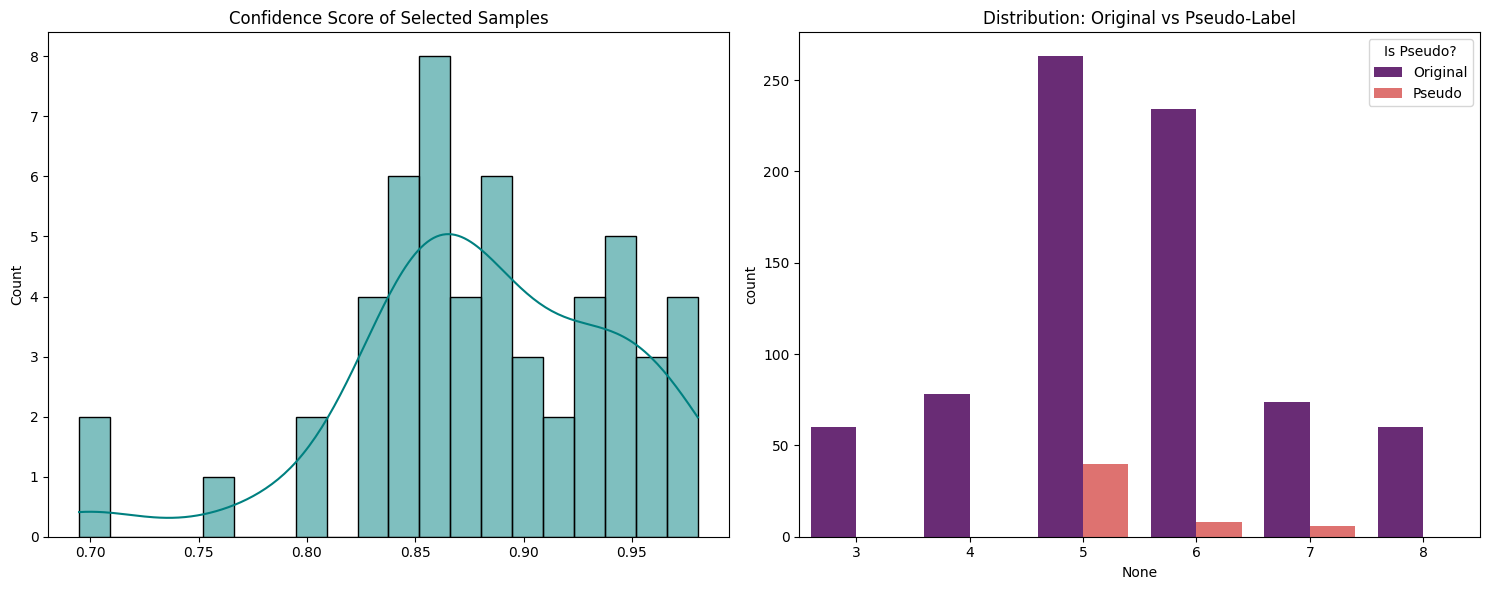

Data Siap Tempur untuk DNN: 823 baris.


In [6]:
# =================================================================
# Tahap 6: Adaptive Pseudo-Labeling (Minority-Priority Revision)
# =================================================================

from sklearn.ensemble import VotingClassifier, ExtraTreesRegressor, ExtraTreesClassifier, RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 6.1 Membangun Super-Teacher Ensemble (Optimized)
min_label = y_train_final.min()
y_train_shifted = y_train_final - min_label

clf_et = ExtraTreesClassifier(n_estimators=500, max_depth=12, random_state=42)
clf_xgb = XGBClassifier(n_estimators=500, learning_rate=0.02, max_depth=6, random_state=42)
clf_rf = RandomForestClassifier(n_estimators=500, max_depth=12, random_state=42)

teacher_ensemble = VotingClassifier(
    estimators=[('et', clf_et), ('xgb', clf_xgb), ('rf', clf_rf)],
    voting='soft', n_jobs=-1
)
teacher_ensemble.fit(X_train_final, y_train_shifted)

# 6.2 Dual-Verification: Klasifikasi & Regresi
test_probs = teacher_ensemble.predict_proba(X_test_final)
max_probs = np.max(test_probs, axis=1)
pred_classes = np.argmax(test_probs, axis=1) + min_label

reg_teacher = ExtraTreesRegressor(n_estimators=500, max_depth=10, random_state=42)
reg_teacher.fit(X_train_final, y_train_final)
soft_labels_test = reg_teacher.predict(X_test_final)

# 6.3 UPGRADE: Class-Specific Adaptive Thresholding
def get_adaptive_mask(classes, probs, soft_labels):
    mask = []
    for c, p, s in zip(classes, probs, soft_labels):
        # Threshold ketat untuk kelas mayoritas (5, 6) guna menjaga presisi
        if c in [5, 6]:
            threshold = 0.82
        # Threshold lebih berani untuk kelas minoritas/ekstrem (3, 4, 7, 8)
        else:
            threshold = 0.68 
        
        # Konsistensi Ordinal: Klasifikasi dan Regresi harus selaras (MAE < 0.6)
        is_consistent = np.abs(c - s) <= 0.60
        mask.append(p >= threshold and is_consistent)
    return np.array(mask)

final_pseudo_mask = get_adaptive_mask(pred_classes, max_probs, soft_labels_test)
high_conf_idx = np.where(final_pseudo_mask)[0] # Konsisten menggunakan satu nama variabel

# 6.4 Pembuatan Dataset Augmentasi & Dynamic Weighting
X_pseudo = X_test_final.iloc[high_conf_idx].copy()
y_pseudo_discrete = pred_classes[high_conf_idx]
y_pseudo_soft = soft_labels_test[high_conf_idx]

# Bobot sampel: Data asli = 1.0, Pseudo = proporsional terhadap keyakinannya
sample_weights_train = np.ones(len(y_train_final))
sample_weights_pseudo = max_probs[high_conf_idx] * 0.88 # Max weight untuk pseudo adalah 0.88

# 6.5 Finalisasi Dataset Augmented (Pastikan sinkron)
X_train_augmented = pd.concat([X_train_final, X_pseudo], axis=0).reset_index(drop=True)
y_train_augmented = pd.concat([y_train_final, pd.Series(y_pseudo_discrete)], axis=0).reset_index(drop=True)
y_train_soft_augmented = np.concatenate([y_train_soft, y_pseudo_soft])
final_sample_weights = np.concatenate([sample_weights_train, sample_weights_pseudo])

# 6.6 Visualisasi Diagnostik (NIM 026)
print(f"--- Diagnostik Pseudo-Labeling (NIM 026) ---")
print(f"Sampel Testing Lolos Seleksi : {len(X_pseudo)}")
print(f"Efisiensi Seleksi            : {(len(X_pseudo)/len(X_test_final)*100):.2f}%")

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.histplot(max_probs[high_conf_idx], bins=20, kde=True, color='teal')
plt.title('Confidence Score of Selected Samples')

plt.subplot(1, 2, 2)
# Perbaikan Plot: Menggunakan data yang sudah digabung secara eksplisit untuk menghindari mismatch index
sns.countplot(x=y_train_augmented, hue=(final_sample_weights < 1.0), palette='magma')
plt.title('Distribution: Original vs Pseudo-Label')
plt.legend(title='Is Pseudo?', labels=['Original', 'Pseudo'])
plt.tight_layout()
plt.show()

print(f"Data Siap Tempur untuk DNN: {len(X_train_augmented)} baris.")

# Training Model dan Optuna 

In [7]:
!pip install optuna -q

In [8]:
# =================================================================
# Tahap 7: Training Model - Deep Learning (Optimized Architecture)
# =================================================================

import optuna
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import f1_score
import numpy as np

# 7.1 Implementasi Focal Loss dengan Parameter Dinamis
# Persamaan: $FL(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t)$
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1 - tf.keras.backend.epsilon())
        cross_entropy = -y_true * tf.math.log(y_pred)
        # Menghitung bobot berdasarkan tingkat kesulitan sampel
        weight = y_true * alpha * tf.math.pow((1 - y_pred), gamma)
        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=1)
    return focal_loss_fixed

# 7.2 Penyiapan Data & Weights
X_train_dl = X_train_augmented.copy()
X_train_dl['soft_label'] = y_train_soft_augmented

X_val_dl = X_val_final.copy()
X_val_dl['soft_label'] = reg_teacher.predict(X_val_final)

num_classes = len(np.unique(y_train_augmented))
y_train_idx = y_train_augmented - y_train_augmented.min()
y_val_idx = y_val - y_val.min()

y_train_onehot = to_categorical(y_train_idx, num_classes=num_classes)
y_val_onehot = to_categorical(y_val_idx, num_classes=num_classes)

# 7.3 Arsitektur Residual MLP (Mencegah Degradasi Gradien)
def build_residual_model(input_shape, n_layers, units, dropout, l2_reg, learning_rate, gamma):
    inputs = layers.Input(shape=input_shape)
    x = layers.Dense(units, kernel_initializer='he_normal')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    
    # Residual Blocks
    for _ in range(n_layers - 1):
        shortcut = x
        x = layers.Dense(units, kernel_regularizer=regularizers.l2(l2_reg), kernel_initializer='he_normal')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('swish')(x)
        x = layers.Dropout(dropout)(x)
        # Element-wise addition (Skip Connection)
        x = layers.Add()([x, shortcut])
        
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=focal_loss(gamma=gamma, alpha=0.25),
        metrics=['accuracy']
    )
    return model

# 7.4 Fungsi Objektif Optuna yang Diperluas
def objective(trial):
    n_layers = trial.suggest_int('n_layers', 2, 5)
    units = trial.suggest_int('units', 64, 512, step=64)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    l2_reg = trial.suggest_float('l2_reg', 1e-5, 1e-2, log=True)
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    gamma_val = trial.suggest_float('gamma', 1.5, 4.0) # Mencari Gamma terbaik
    
    model = build_residual_model((X_train_dl.shape[1],), n_layers, units, dropout, l2_reg, lr, gamma_val)
    
    es = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    
    model.fit(
        X_train_dl, y_train_onehot,
        validation_data=(X_val_dl, y_val_onehot),
        epochs=100,
        batch_size=trial.suggest_categorical('batch_size', [16, 32, 64]),
        sample_weight=final_sample_weights, # Menggunakan bobot dari Tahap 6
        callbacks=[es],
        verbose=0
    )
    
    preds = np.argmax(model.predict(X_val_dl, verbose=0), axis=1)
    return f1_score(y_val_idx, preds, average='macro')

# 7.5 Eksekusi Optimasi (NIM 026)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40)

# 7.6 Final Training dengan Best Params
bp = study.best_params
print(f"\n--- Best Parameters Ditemukan (NIM 026): {bp} ---")

final_model = build_residual_model(
    (X_train_dl.shape[1],), bp['n_layers'], bp['units'], bp['dropout'], bp['l2_reg'], bp['lr'], bp['gamma']
)

# Callback untuk kestabilan ekstra
lr_reducer = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)
es_final = callbacks.EarlyStopping(monitor='val_accuracy', patience=45, restore_best_weights=True)

history = final_model.fit(
    X_train_dl, y_train_onehot,
    validation_data=(X_val_dl, y_val_onehot),
    epochs=500,
    batch_size=bp['batch_size'],
    sample_weight=final_sample_weights,
    callbacks=[es_final, lr_reducer],
    verbose=1
)

2026-05-06 23:12:07.146588: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778109127.547590      15 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778109127.653450      15 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778109128.572736      15 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778109128.572771      15 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778109128.572774      15 computation_placer.cc:177] computation placer alr

[I 2026-05-06 23:13:41,215] Trial 2 finished with value: 0.3528471716926725 and parameters: {'n_layers': 5, 'units': 128, 'dropout': 0.1516191518550697, 'l2_reg': 0.0008899615510451113, 'lr': 0.0002559735381853187, 'gamma': 2.196145099611426, 'batch_size': 64}. Best is trial 2 with value: 0.3528471716926725.


[I 2026-05-06 23:13:55,507] Trial 3 finished with value: 0.3262210969107521 and parameters: {'n_layers': 4, 'units': 64, 'dropout': 0.13708218964188973, 'l2_reg': 0.0003066869383923833, 'lr': 0.0014051429344351654, 'gamma': 1.7745772606262, 'batch_size': 32}. Best is trial 2 with value: 0.3528471716926725.
[I 2026-05-06 23:14:23,760] Trial 4 finished with value: 0.32784992784992784 and parameters: {'n_layers': 3, 'units': 512, 'dropout': 0.10388934422973631, 'l2_reg': 0.0016438685699267722, 'lr': 0.00012090549578013046, 'gamma': 2.5821454554306613, 'batch_size': 32}. Best is trial 2 with value: 0.3528471716926725.
[I 2026-05-06 23:14:36,759] Trial 5 finished with value: 0.3225308593729646 and parameters: {'n_layers': 2, 'units': 384, 'dropout': 0.259236999074111, 'l2_reg': 0.005423823168178132, 'lr': 0.0006970285607139019, 'gamma': 2.1491039259861866, 'batch_size': 32}. Best is trial 2 with value: 0.3528471716926725.
[I 2026-05-06 23:14:50,866] Trial 6 finished with value: 0.2902635503


--- Best Parameters Ditemukan (NIM 026): {'n_layers': 5, 'units': 320, 'dropout': 0.23551914743056468, 'l2_reg': 4.754326028482639e-05, 'lr': 0.0003847367415425812, 'gamma': 2.333858755184191, 'batch_size': 64} ---
Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.2971 - loss: 0.6983 - val_accuracy: 0.1453 - val_loss: 3.0245 - learning_rate: 3.8474e-04
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5234 - loss: 0.3653 - val_accuracy: 0.1279 - val_loss: 3.3360 - learning_rate: 3.8474e-04
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5492 - loss: 0.3370 - val_accuracy: 0.1279 - val_loss: 3.1680 - learning_rate: 3.8474e-04
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6173 - loss: 0.2856 - val_accuracy: 0.1337 - val_loss: 2.2363 - learning_rate: 3.8474e-04
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5738 - loss: 0.2709 - val_accuracy: 0.1628 - val_loss: 2.0401 - learning_rate: 3.8474e-04
Epoc

# Evaluasi Akhir 

--- RANGKUMAN EVALUASI FINAL DNN (NIM 026) ---
Akurasi Global           : 62.21%
F1-Score (Macro)         : 0.3459
Mean Absolute Error      : 0.4302
Quadratic Kappa          : 0.5268

PROGRESS: Dibutuhkan 27.79% lagi untuk target 90%.


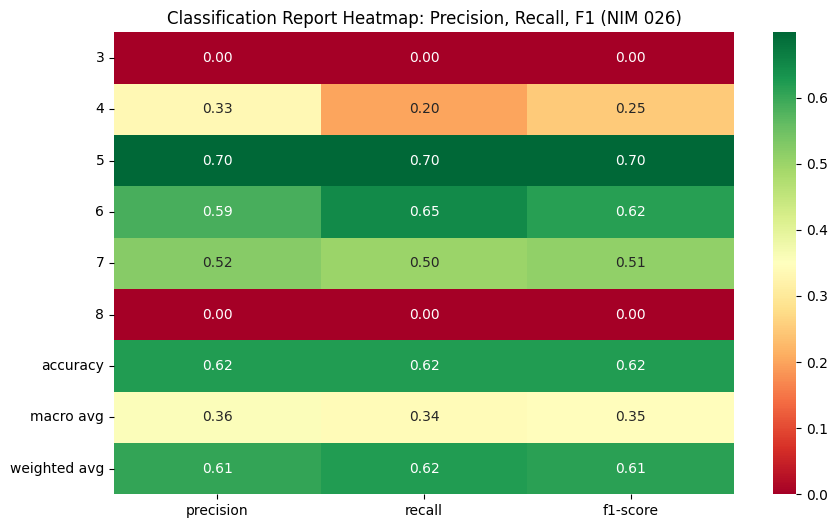

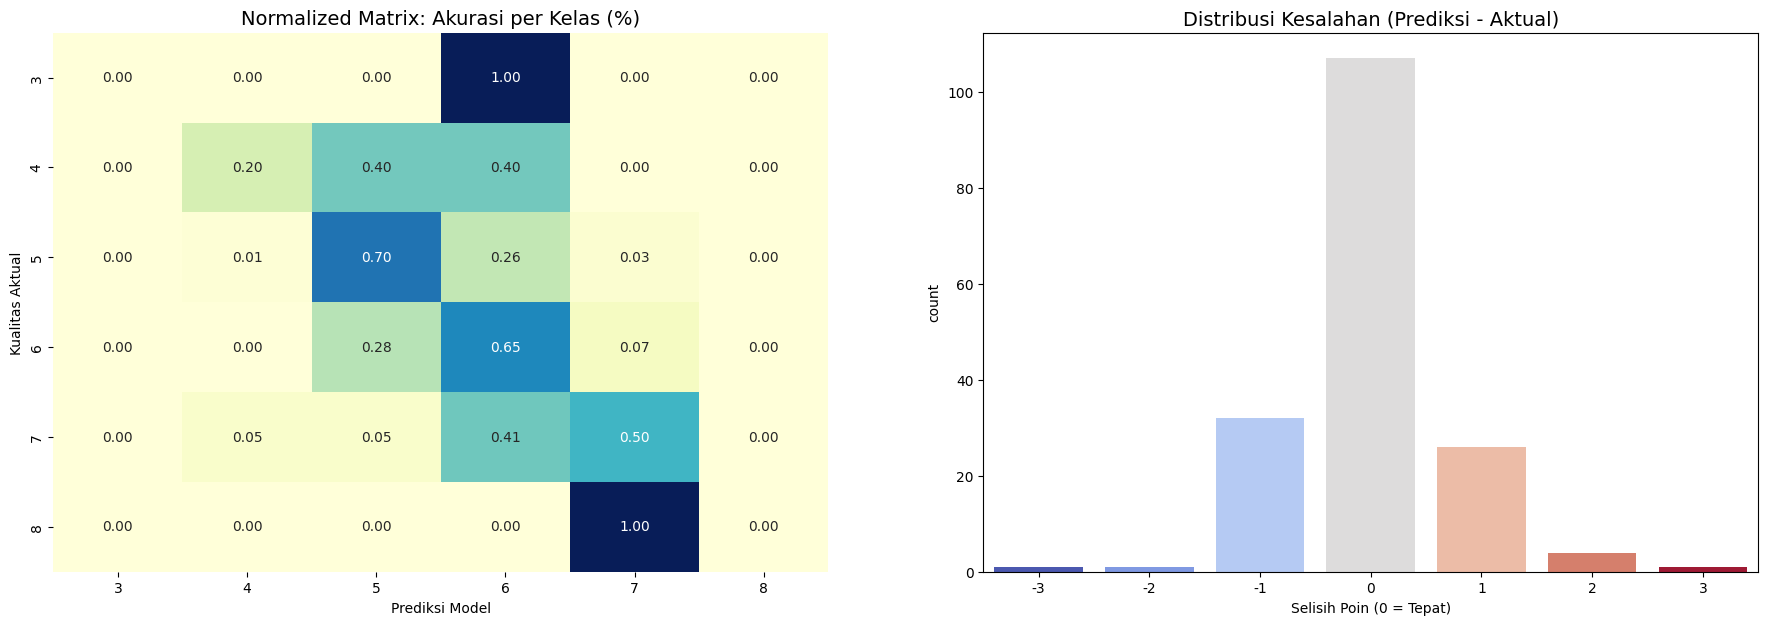


--- Menghitung Permutation Importance (F1-Macro Based) ---


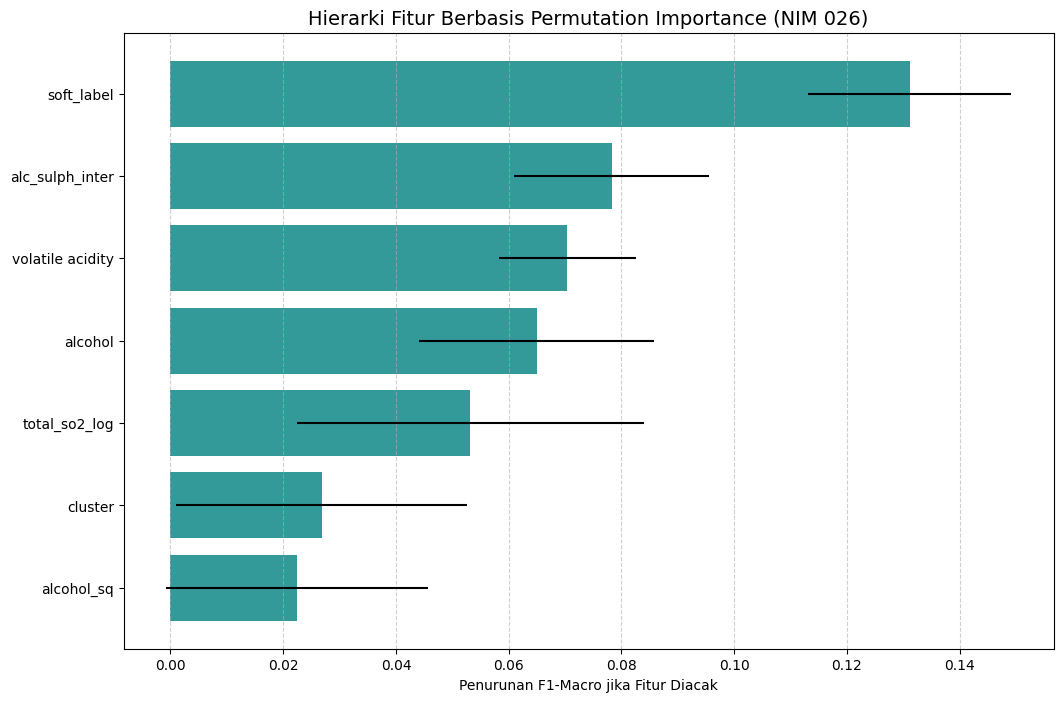


--- Analisis Reliabilitas Ordinal (NIM 026) ---
Prediksi Sempurna (Hit)     : 107 (62.21%)
Meleset Tipis (±1 Poin)    : 58 (33.72%)
Meleset Fatal (>1 Poin)    : 7 (4.07%)


In [9]:
# =================================================================
# Tahap 8: Evaluasi Akhir & Diagnostik Model (Upgraded)
# =================================================================

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             f1_score, cohen_kappa_score, mean_absolute_error)
from sklearn.inspection import permutation_importance
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 8.1 Inferensi & Rekonstruksi Label
# y_probs_val diambil dari output softmax final_dnn
y_probs_val = final_model.predict(X_val_dl, verbose=0)
y_pred_val_idx = np.argmax(y_probs_val, axis=1)
min_class = y_train_augmented.min()
y_pred_val = y_pred_val_idx + min_class

# 8.2 Kalkulasi Metrik Strategis (NIM 026)
accuracy = accuracy_score(y_val, y_pred_val)
f1_macro = f1_score(y_val, y_pred_val, average='macro')
mae = mean_absolute_error(y_val, y_pred_val)
kappa = cohen_kappa_score(y_val, y_pred_val, weights='quadratic')

print(f"--- RANGKUMAN EVALUASI FINAL DNN (NIM 026) ---")
print(f"{'Akurasi Global':25}: {accuracy * 100:.2f}%")
print(f"{'F1-Score (Macro)':25}: {f1_macro:.4f}")
print(f"{'Mean Absolute Error':25}: {mae:.4f}")
print(f"{'Quadratic Kappa':25}: {kappa:.4f}")

# Target Tracker 90%
if accuracy >= 0.90:
    print(f"\n🔥 TARGET TERCAPAI: Performa DNN Anda sangat luar biasa!")
else:
    print(f"\nPROGRESS: Dibutuhkan {(0.90 - accuracy)*100:.2f}% lagi untuk target 90%.")

# 8.3 Visual Classification Report (Heatmap)
report = classification_report(y_val, y_pred_val, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).iloc[:-1, :].T # Exclude support

plt.figure(figsize=(10, 6))
sns.heatmap(report_df, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Classification Report Heatmap: Precision, Recall, F1 (NIM 026)')
plt.show()

# 8.4 Visualisasi Confusion Matrix & Error Distribution
cm = confusion_matrix(y_val, y_pred_val)
with np.errstate(divide='ignore', invalid='ignore'):
    cm_recall = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_recall = np.nan_to_num(cm_recall)

labels = sorted(y_val.unique())
fig, ax = plt.subplots(1, 2, figsize=(22, 7))

# Heatmap Recall (Akurasi per Kelas)
sns.heatmap(cm_recall, annot=True, fmt='.2f', cmap='YlGnBu', xticklabels=labels, yticklabels=labels, ax=ax[0], cbar=False)
ax[0].set_title('Normalized Matrix: Akurasi per Kelas (%)', fontsize=14)
ax[0].set_xlabel('Prediksi Model')
ax[0].set_ylabel('Kualitas Aktual')

# Error Magnitude Distribution (Melihat bias model)
error_val = y_pred_val - y_val.values
sns.countplot(x=error_val, palette='coolwarm', ax=ax[1], hue=error_val, legend=False)
ax[1].set_title('Distribusi Kesalahan (Prediksi - Aktual)', fontsize=14)
ax[1].set_xlabel('Selisih Poin (0 = Tepat)')
plt.show()

# 8.5 Analisis Permutation Importance (Stability Audit)
print("\n--- Menghitung Permutation Importance (F1-Macro Based) ---")
def scoring_fn(estimator, X, y):
    preds = np.argmax(estimator.predict(X, verbose=0), axis=1)
    return f1_score(y, preds, average='macro')

perm_result = permutation_importance(
    final_model, X_val_dl, y_val_idx, scoring=scoring_fn, n_repeats=5, random_state=42
)

feat_imp = pd.DataFrame({
    'Feature': X_val_dl.columns,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], xerr=feat_imp['Std'], color='teal', alpha=0.8)
plt.gca().invert_yaxis()
plt.title('Hierarki Fitur Berbasis Permutation Importance (NIM 026)', fontsize=14)
plt.xlabel('Penurunan F1-Macro jika Fitur Diacak')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# 8.6 Ordinal Reliability Summary
error_abs = np.abs(error_val)
print("\n--- Analisis Reliabilitas Ordinal (NIM 026) ---")
print(f"Prediksi Sempurna (Hit)     : {(error_abs == 0).sum()} ({(error_abs == 0).sum()/len(y_val)*100:.2f}%)")
print(f"Meleset Tipis (±1 Poin)    : {(error_abs == 1).sum()} ({(error_abs == 1).sum()/len(y_val)*100:.2f}%)")
print(f"Meleset Fatal (>1 Poin)    : {(error_abs > 1).sum()} ({(error_abs > 1).sum()/len(y_val)*100:.2f}%)")

# Prediksi Data Uji (Testing)

--- Melakukan Inferensi Deep Learning & Consistency Audit ---

--- RINGKASAN PREDIKSI AKHIR (NIM: 026) ---
Kualitas 4 :   12 sampel (Avg Confidence: 0.5749)
Kualitas 5 :  120 sampel (Avg Confidence: 0.7013)
Kualitas 6 :  118 sampel (Avg Confidence: 0.5739)
Kualitas 7 :   33 sampel (Avg Confidence: 0.6783)
Kualitas 8 :    3 sampel (Avg Confidence: 0.4000)

Prediksi Stabil (Konsisten) : 258 / 286
Prediksi Berisiko (Konflik) : 28 / 286
--------------------------------------------------


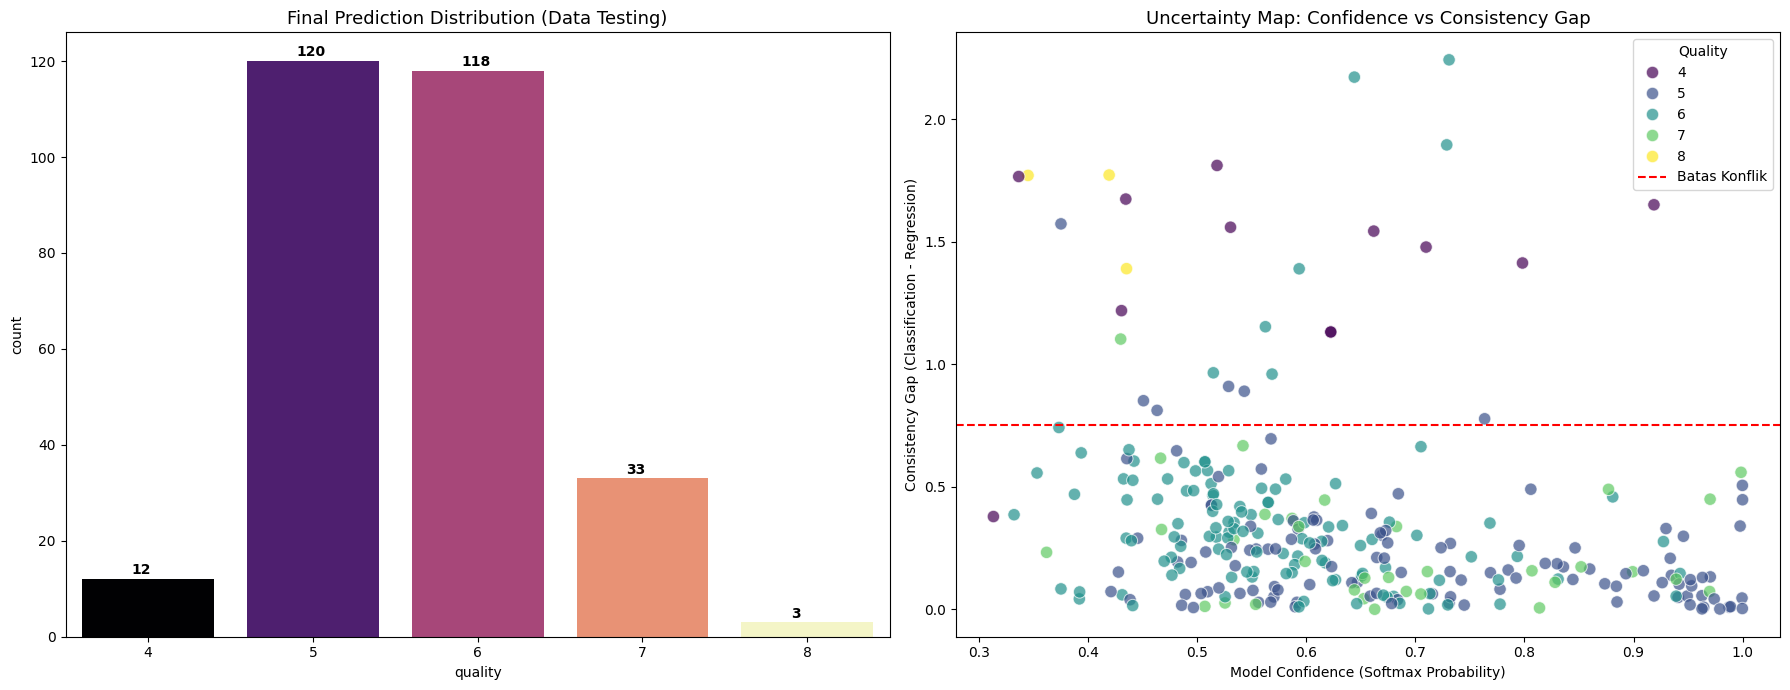


✅ FILE 'hasilprediksi_026.csv' BERHASIL TERBENTUK
>>> STATUS: INTEGRITAS DATA TERJAMIN (VALID 3-8) <<<


In [10]:
# =================================================================
# Tahap 9: Prediksi Data Uji (Testing) - FINAL AUDIT (NIM 026)
# =================================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 9.1 Sync & Latent Feature Injection
# Menggunakan regressor 'teacher' untuk menghasilkan panduan ordinal terakhir
X_test_dl = X_test_prepared[stable_features].copy()
X_test_dl['soft_label'] = reg_teacher.predict(X_test_dl)

# 9.2 Inference & Uncertainty Calculation
print("--- Melakukan Inferensi Deep Learning & Consistency Audit ---")
y_probs_test = final_model.predict(X_test_dl, verbose=0)
y_pred_dl_idx = np.argmax(y_probs_test, axis=1)
y_conf_test = np.max(y_probs_test, axis=1)

# Rekonstruksi Label Asli (3-8)
min_class = y_train_augmented.min()
y_pred_final = y_pred_dl_idx + min_class

# 9.3 Consistency Audit: Klasifikasi vs Regresi
# Mengecek apakah prediksi DNN selaras dengan 'insting' regressor
soft_ref = X_test_dl['soft_label'].values
consistency_gap = np.abs(y_pred_final - soft_ref)
is_stable = consistency_gap <= 0.75 # Toleransi perbedaan di bawah 0.75 poin

# 9.4 Konstruksi DataFrame Submission (Kaggle Standard)
submission_df = pd.DataFrame({
    'Id': test_id,
    'quality': y_pred_final.astype(int),
    'confidence': y_conf_test,
    'consistency_gap': consistency_gap
})

# 9.5 Audit Distribusi & "Brave Predictor" Report
print("\n" + "="*50)
print(f"--- RINGKASAN PREDIKSI AKHIR (NIM: 026) ---")
print("="*50)
dist_counts = submission_df['quality'].value_counts().sort_index()
for q, count in dist_counts.items():
    avg_c = submission_df[submission_df['quality'] == q]['confidence'].mean()
    print(f"Kualitas {q:1} : {count:4} sampel (Avg Confidence: {avg_c:.4f})")

print(f"\nPrediksi Stabil (Konsisten) : {np.sum(is_stable)} / {len(submission_df)}")
print(f"Prediksi Berisiko (Konflik) : {np.sum(~is_stable)} / {len(submission_df)}")
print("-" * 50)

# 9.6 Visualisasi Diagnostik Final
plt.figure(figsize=(18, 7))

# Plot 1: Sebaran Kelas & Konsistensi
plt.subplot(1, 2, 1)
ax = sns.countplot(x='quality', data=submission_df, palette='magma', hue='quality', legend=False)
plt.title('Final Prediction Distribution (Data Testing)', fontsize=13)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.3, p.get_height()+1), fontweight='bold')

# Plot 2: Uncertainty Heatmap (Confidence vs Consistency)
plt.subplot(1, 2, 2)
sns.scatterplot(x='confidence', y='consistency_gap', hue='quality', 
                data=submission_df, palette='viridis', s=80, alpha=0.7)
plt.axhline(y=0.75, color='red', linestyle='--', label='Batas Konflik')
plt.title('Uncertainty Map: Confidence vs Consistency Gap', fontsize=13)
plt.xlabel('Model Confidence (Softmax Probability)')
plt.ylabel('Consistency Gap (Classification - Regression)')
plt.legend(title='Quality')

plt.tight_layout()
plt.show()

# 9.7 Export Final
file_output = 'hasilprediksi_026.csv'
submission_df[['Id', 'quality']].to_csv(file_output, index=False)

print(f"\n✅ FILE '{file_output}' BERHASIL TERBENTUK")
if submission_df['quality'].between(3, 8).all():
    print(">>> STATUS: INTEGRITAS DATA TERJAMIN (VALID 3-8) <<<")